## Sub questions: 
- Use Total Least Squares and report resulting parameter
- Run RANSAC

## (a) Use Total Least Squares and report resulting parameter

In [1]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# Load the dataset

D = np.genfromtxt('../lines.csv', delimiter=',', skip_header=1)

X_cols = D[:, :3]   # x1, x2, x3
Y_cols = D[:, 3:]   # y1, y2, y3

print('Dataset shape      :', D.shape)
print('Points per line    :', D.shape[0])
print()
print('First 5 rows of Line 1  (x1, y1):')
print(f'  {"x1":>10}   {"y1":>12}')
for i in range(5):
    print(f'  {X_cols[i, 0]:>10.4f}   {Y_cols[i, 0]:>12.4f}')


Dataset shape      : (100, 6)
Points per line    : 100

First 5 rows of Line 1  (x1, y1):
          x1             y1
     -5.3055       -12.6663
     -5.5404       -11.0077
     -4.9821       -11.6973
     -4.4957       -11.9780
     -4.4422       -12.4150


In [3]:
# Use only Line 1: x1 and y1
X_line1 = np.hstack((X_cols[:, 0].reshape(-1, 1),
                     Y_cols[:, 0].reshape(-1, 1)))

print('X_line1 shape :', X_line1.shape)
print('x range       : [{:.4f},  {:.4f}]'.format(X_line1[:, 0].min(), X_line1[:, 0].max()))
print('y range       : [{:.4f},  {:.4f}]'.format(X_line1[:, 1].min(), X_line1[:, 1].max()))


X_line1 shape : (100, 2)
x range       : [-5.5404,  5.7400]
y range       : [-12.6663,  0.2031]


In [4]:
# Total Least Squares

X_ = X_line1

# Step 1: Center the data (subtract column means)
U = X_ - np.mean(X_, axis=0)

# Step 2: SVD of U^T U
_, _, Vt = np.linalg.svd(np.transpose(U) @ U)

# Step 3: Extract line normal (a, b)
a, b = Vt[-1, 0], Vt[-1, 1]

# Step 4: Compute d so the line passes through the centroid
d = a * np.mean(X_[:, 0]) + b * np.mean(X_[:, 1])

# Store as [a, b, d]
best_model_line1 = np.array([a, b, d])

# Print results
print('=' * 48)
print('Q1a — TLS Results')
print('=' * 48)
print()
print('best_model_line1 [a, b, d] =', best_model_line1)
print()
print(f'Line equation  :  {a:.6f}·x  +  {b:.6f}·y  =  {d:.6f}')
print(f'Slope-intercept:  y  =  {-a/b:.6f}·x  +  {d/b:.6f}')


Q1a — TLS Results

best_model_line1 [a, b, d] = [-0.77356165  0.63372105 -3.79419221]

Line equation  :  -0.773562·x  +  0.633721·y  =  -3.794192
Slope-intercept:  y  =  1.220666·x  +  -5.987165


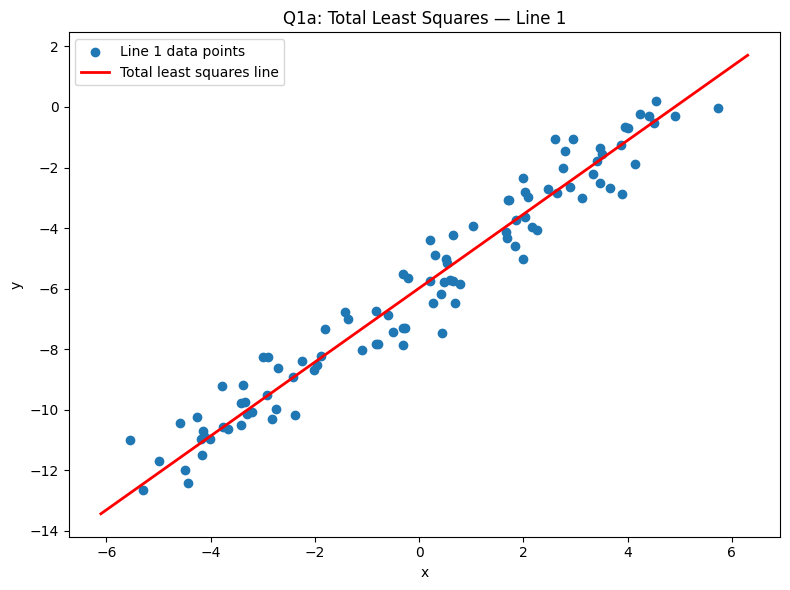

Saved → outputs/q1/q1a_tls.png


In [5]:
# Plot Q1a result

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot the data points
ax.scatter(X_line1[:, 0], X_line1[:, 1], label='Line 1 data points')

# Draw the fitted line
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = (-best_model_line1[0] * x_ + best_model_line1[2]) / best_model_line1[1]
ax.plot(x_, y_, color='r', linewidth=2, label='Total least squares line')

ax.set_title('Q1a: Total Least Squares — Line 1')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.tight_layout()
os.makedirs('../outputs/q1', exist_ok=True)
plt.savefig('../outputs/q1/q1a_tls.png', dpi=130)
plt.show()
print('Saved → outputs/q1/q1a_tls.png')


# (b) RANSAC: Fitting 3 Lines from All Points

In [6]:
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

print('Total points   :', len(X_all))
print('X range        : [{:.4f},  {:.4f}]'.format(X_all.min(), X_all.max()))
print('Y range        : [{:.4f},  {:.4f}]'.format(Y_all.min(), Y_all.max()))

# Stack into Nx2 matrix
X_all_pts = np.hstack((X_all.reshape(-1, 1), Y_all.reshape(-1, 1)))
print('Stacked shape  :', X_all_pts.shape)


Total points   : 300
X range        : [-5.5404,  5.7400]
Y range        : [-12.6663,  5.8830]
Stacked shape  : (300, 2)


In [7]:
# TLS helper function

def fit_tls(X_pts):
    U = X_pts - np.mean(X_pts, axis=0)              # center the data
    _, _, Vt = np.linalg.svd(np.transpose(U) @ U)   # SVD of U^T U
    a, b = Vt[-1, 0], Vt[-1, 1]                     # last row = line normal
    d = a * np.mean(X_pts[:, 0]) + b * np.mean(X_pts[:, 1])
    return np.array([a, b, d])


In [8]:
# Distance function

def distance_to_line(model, x, y):
    a, b, d = model[0], model[1], model[2]
    return (a * x + b * y - d) ** 2


In [9]:
# RANSAC function

def ransac_line(X_pts, thresh=1.0, max_iterations=500):
    N = len(X_pts)
    best_model     = None
    best_consensus = []          # best inlier boolean mask found so far

    for iteration in range(max_iterations):

        # 1. Pick 2 random points
        samples = np.random.choice(N, 2, replace=False)

        # 2. Fit TLS through those 2 points
        model = fit_tls(X_pts[samples])

        # 3. Count inliers — all points within threshold
        dist      = distance_to_line(model, X_pts[:, 0], X_pts[:, 1])
        consensus = dist < thresh

        # 4. Keep the best consensus seen so far
        if consensus.sum() > len(best_consensus):
            best_consensus = consensus
            best_model     = model

    # 5. Refit using ALL inliers
    best_model = fit_tls(X_pts[best_consensus])

    return best_model, best_consensus


Q1b — RANSAC Sequential Line Fitting

Line 1:
  Parameters      : a=0.4204,  b=0.9073,  d=1.8828
  Slope-intercept : y = -0.4633x + 2.0750
  Inliers found   : 116 / 300

Line 2:
  Parameters      : a=-0.7845,  b=0.6202,  d=-3.7859
  Slope-intercept : y = 1.2649x + -6.1046
  Inliers found   : 84 / 184

Line 3:
  Parameters      : a=-0.7222,  b=0.6917,  d=0.6717
  Slope-intercept : y = 1.0441x + 0.9711
  Inliers found   : 82 / 100



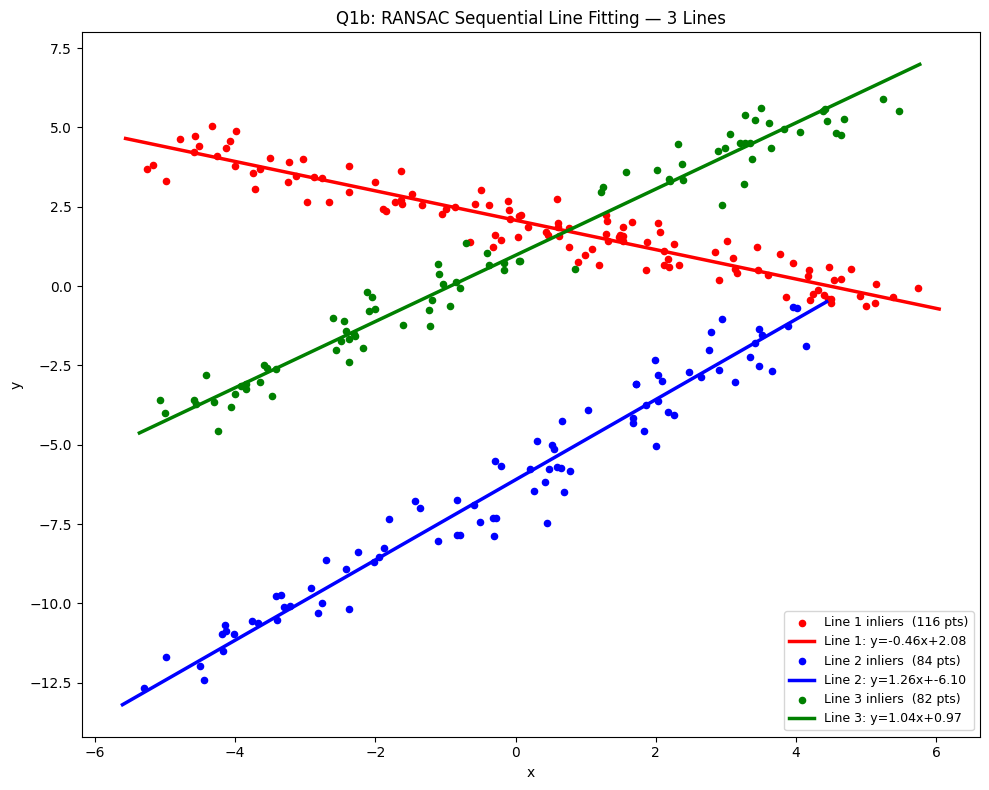

Saved → outputs/q1/q1b_ransac.png


In [10]:
# Run RANSAC 3 times with sequential masking

np.random.seed(42)    # for reproducibility

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

colors = ['red', 'blue', 'green']

# Boolean: True = this point has not yet been assigned to any line
remaining = np.ones(len(X_all_pts), dtype=bool)

print('=' * 55)
print('Q1b — RANSAC Sequential Line Fitting')
print('=' * 55)
print()

for i in range(3):

    # Run RANSAC on remaining points only
    X_remaining            = X_all_pts[remaining]
    model, consensus_local = ransac_line(X_remaining, thresh=1.0, max_iterations=500)

    a, b, d = model[0], model[1], model[2]

    print(f'Line {i+1}:')
    print(f'  Parameters      : a={a:.4f},  b={b:.4f},  d={d:.4f}')
    print(f'  Slope-intercept : y = {-a/b:.4f}x + {d/b:.4f}')
    print(f'  Inliers found   : {consensus_local.sum()} / {len(X_remaining)}')
    print()

    # Map local inlier indices → global indices
    # np.where(remaining)[0] gives the global index of each remaining point
    global_indices = np.where(remaining)[0]
    inlier_global  = global_indices[consensus_local]

    # Plot inlier points and fitted line
    ax.scatter(X_all_pts[inlier_global, 0], X_all_pts[inlier_global, 1],
               color=colors[i], s=20,
               label=f'Line {i+1} inliers  ({consensus_local.sum()} pts)')

    x_min = X_all_pts[inlier_global, 0].min()
    x_max = X_all_pts[inlier_global, 0].max()
    x_ = np.array([x_min - 0.3, x_max + 0.3])
    y_ = (-a * x_ + d) / b
    ax.plot(x_, y_, color=colors[i], linewidth=2.5,
            label=f'Line {i+1}: y={-a/b:.2f}x+{d/b:.2f}')

    # Remove inliers from the pool so the next run ignores them
    remaining[inlier_global] = False

ax.set_title('Q1b: RANSAC Sequential Line Fitting — 3 Lines')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(fontsize=9)
plt.tight_layout()
os.makedirs('../outputs/q1', exist_ok=True)
plt.savefig('../outputs/q1/q1b_ransac.png', dpi=130)
plt.show()
print('Saved → outputs/q1/q1b_ransac.png')
